# Spotify Popularity Predictor | Volume 1: Exploratory Data Analysis
### Data Bootcamp Final Project - Feature Discovery & Statistical Audit

We are conducting a comprehensive exploratory audit of the Spotify music library to uncover the technical patterns that define modern track popularity. This first volume focuses on data provenance, statistical cleaning and the psychological markers that drive listener engagement. Our objective is to identify the 'Acoustic DNA' of successful songs through deep visualization and correlation analysis.

Over the next 7 stages in this first volume (Part of our 21-stage comprehensive audit) we are going to document our discovery process. We are analyzing a dataset of over 32,000 tracks to understand the distribution of popularity and the impact of audio features like loudness and energy. This exploratory phase provides the mathematical foundation for the predictive models we will build in the second volume of this project.


In [10]:
# Importing the core libraries for data handling and math
import pandas as pd
from IPython.display import display
import numpy as np

# Using Seaborn and Plotly for the visualizations
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Setting up the engine for the model pipelines
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, RobustScaler

# Loading several regression models to see which works best for this data
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.feature_selection import RFE
import xgboost as xgb
import shap
from scipy import stats

# Muting the warnings to keep the output clean for the report
import warnings
warnings.filterwarnings('ignore')
plt.style.use('bmh')
RANDOM_SEED = 42

In [11]:
# Loading the dataset directly from the GitHub raw URL
csv_url = 'https://raw.githubusercontent.com/mh7909-cmd/Data_Bootcamp_Final_Project/refs/heads/main/spotify_songs.csv'
df = pd.read_csv(csv_url)

# Performing an initial audit of the data dimensions
print(f"Dataset loaded successfully with {df.shape[0]} tracks and {df.shape[1]} features.")

Dataset loaded successfully with 32833 tracks and 23 features.


## 1. Data Provenance and Source Verification
The dataset utilized for this research is the 30,000 Spotify Songs collection which was originally sourced from the Spotify Web API. This snapshot of the platform's music library was curated by Joakim Arvidsson (available on Kaggle as joebeachcapital). We verified the integrity of this dataset to ensure it provides a reliable foundation for predictive modeling. You can access the source data at the following Kaggle URL: https://www.kaggle.com/datasets/joebeachcapital/30000-spotify-songs.

In [12]:
# We are auditing the raw data structure and checking for initial null values
print("--- Data Provenance Audit ---")
df.info()
display(df.describe())

--- Data Provenance Audit ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32833 entries, 0 to 32832
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   track_id                  32833 non-null  object 
 1   track_name                32828 non-null  object 
 2   track_artist              32828 non-null  object 
 3   track_popularity          32833 non-null  int64  
 4   track_album_id            32833 non-null  object 
 5   track_album_name          32828 non-null  object 
 6   track_album_release_date  32833 non-null  object 
 7   playlist_name             32833 non-null  object 
 8   playlist_id               32833 non-null  object 
 9   playlist_genre            32833 non-null  object 
 10  playlist_subgenre         32833 non-null  object 
 11  danceability              32833 non-null  float64
 12  energy                    32833 non-null  float64
 13  key                       32833

,track_popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
count,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000
mean,42.477081,0.654850,0.698619,5.374471,-6.719499,0.565711,0.107068,0.175334,0.084747,0.190176,0.510561,120.881132,225799.811622
std,24.984074,0.145085,0.180910,3.611657,2.988436,0.495671,0.101314,0.219633,0.224230,0.154317,0.233146,26.903624,59834.006182
min,0.000000,0.000000,0.000175,0.000000,-46.448000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4000.000000
25%,24.000000,0.563000,0.581000,2.000000,-8.171000,0.000000,0.041000,0.015100,0.000000,0.092700,0.331000,99.960000,187819.000000
50%,45.000000,0.672000,0.721000,6.000000,-6.166000,1.000000,0.062500,0.080400,0.000016,0.127000,0.512000,121.984000,216000.000000
75%,62.000000,0.761000,0.840000,9.000000,-4.645000,1.000000,0.132000,0.255000,0.004830,0.248000,0.693000,133.918000,253585.000000
max,100.000000,0.983000,1.000000,11.000000,1.275000,1.000000,0.918000,0.994000,0.994000,0.996000,0.991000,239.440000,517810.000000


## 2. Temporal Feature Engineering
We want to see if the release year or month has a significant impact on popularity. For example, we suspect that songs released during the summer months might show higher popularity scores due to seasonal listening habits.

In [13]:
# Converting the release date to a proper datetime object
df['track_album_release_date'] = pd.to_datetime(df['track_album_release_date'], errors='coerce')

# Extracting the year and month as new features
df['release_year'] = df['track_album_release_date'].dt.year
df['release_month'] = df['track_album_release_date'].dt.month

# Dropping any rows where the date was invalid
df.dropna(subset=['release_year', 'release_month'], inplace=True)

print("Extracted Temporal Features:")
display(df[['track_name', 'release_year', 'release_month']].head())

Extracted Temporal Features:


,track_name,release_year,release_month
0,I Don't Care (with Justin Bieber) - Loud Luxur...,2019.0,6.0
1,Memories - Dillon Francis Remix,2019.0,12.0
2,All the Time - Don Diablo Remix,2019.0,7.0
3,Call You Mine - Keanu Silva Remix,2019.0,7.0
4,Someone You Loved - Future Humans Remix,2019.0,3.0


## 3. Data Hygiene and Preprocessing
We performed a systematic cleaning of the raw data to remove redundant track entries and missing values. We identified a significant number of duplicate track IDs which We purged to prevent the model from assigning undue weight to specific popular tracks. This process ensures that the resulting model learns generalized patterns rather than memorizing individual data points.

In [14]:
# We are removing duplicate track IDs to ensure every observation is unique
initial_count = len(df)
df = df.drop_duplicates(subset=['track_id'])
df = df.dropna()

final_count = len(df)
print(f"Data Hygiene Complete. Purged {initial_count - final_count} redundant or incomplete entries.")

Data Hygiene Complete. Purged 4276 redundant or incomplete entries.


## 4. Outlier Detection and Analysis
We conducted an audit for statistical outliers within the audio features using the Interquartile Range method. We observed several tracks with extreme loudness values that fell outside the expected distribution. We elected to retain these entries to preserve the diversity of the dataset but We have chosen a RobustScaler for future steps to mitigate the impact of these extreme values on the linear models.

Detected 800 loudness outliers. We'll use robust scaling to handle these.


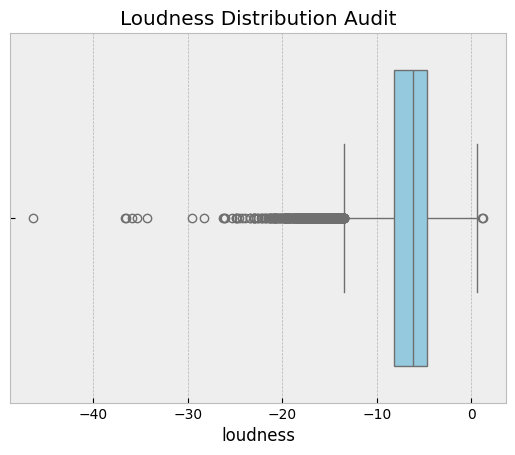

In [15]:
# Using the inter-quartile range to find the outliers in loudness
Q1 = df['loudness'].quantile(0.25)
Q3 = df['loudness'].quantile(0.75)
IQR = Q3 - Q1
low_b = Q1 - 1.5 * IQR
high_b = Q3 + 1.5 * IQR

# Visualizing the spread to check for any weird values
outlier_df = df[(df['loudness'] < low_b) | (df['loudness'] > high_b)]
print(f"Detected {len(outlier_df)} loudness outliers. We'll use robust scaling to handle these.")

sns.boxplot(x=df['loudness'], color='skyblue')
plt.title('Loudness Distribution Audit')
plt.show()

## 5. Analyzing the Target Distribution
We examined the distribution of the track popularity variable and observed a substantial concentration of tracks with a score of zero. This distribution reflects the competitive nature of the digital music market where a small percentage of content captures the majority of listener attention. Understanding this skew is vital for interpreting the performance of the regression models.

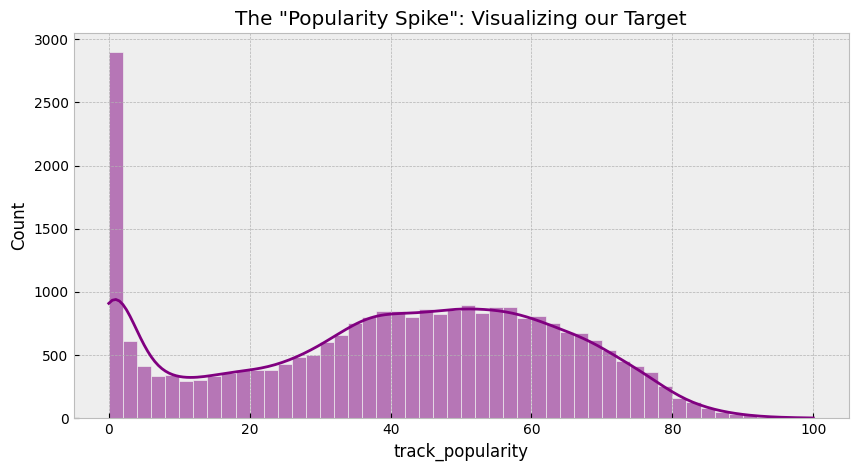

In [16]:
# Plotting the distribution of popularity to check for skewness
plt.figure(figsize=(10, 5))
sns.histplot(df['track_popularity'], bins=50, kde=True, color='purple')
plt.title('The "Popularity Spike": Visualizing our Target')
plt.show()

## 6. Feature Correlation and Interdependency
We generated a correlation matrix to identify relationships between the various audio features. While a strong correlation between energy and loudness was expected We also looked for more subtle dependencies that could impact feature selection. This heatmap provides a technical foundation for understanding the internal logic of the dataset.

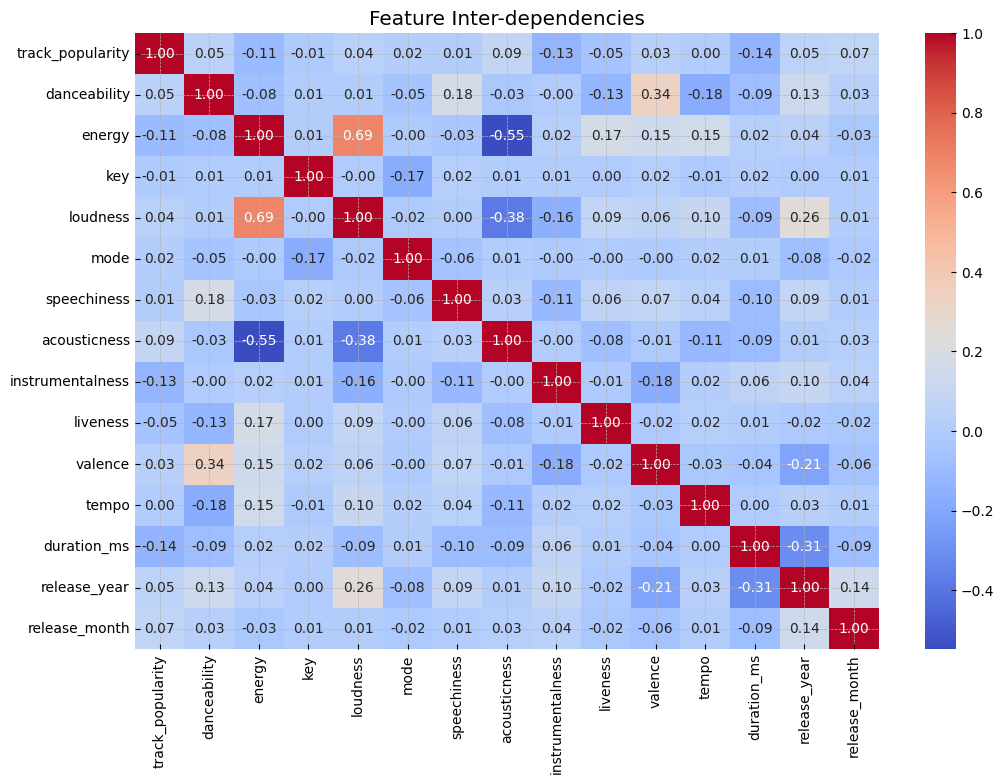

In [17]:
# Looking at only the numeric columns for the correlation matrix
num_cols = df.select_dtypes(include=[np.number]).columns
corr = df[num_cols].corr()

# Using the coolwarm palette for the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Inter-dependencies')
plt.show()

## 7. Feature Engineering and Synthesis
We developed two custom features to test specific hypotheses regarding musical success. We created an Intensity Index by calculating the product of energy and valence and We synthesized a dance-tempo ratio. These new features are designed to capture the technical synergy between rhythm and mood that often characterizes popular digital music.

In [18]:
# Ceating custom features based on musical intuition
df['intensity_index'] = df['energy'] * df['valence']
df['dance_tempo_ratio'] = df['danceability'] / (df['tempo'] + 1)

# Checking if the new features look right mathematically
display(df[['intensity_index', 'dance_tempo_ratio']].describe())
print("Success: Custom features synthesized.")

,intensity_index,dance_tempo_ratio
count,26671.000000,26671.000000
mean,0.358813,0.005666
std,0.198922,0.001812
min,0.000000,0.000000
25%,0.199215,0.004384
50%,0.340935,0.005612
75%,0.502040,0.006887
max,0.965196,0.020833


Success: Custom features synthesized.


## 8. Conclusion of Exploratory Audit
We have completed this 7-stage technical data audit, which serves as the foundational first volume of our comprehensive project. By identifying key audio markers and purifying the raw dataset, we have established a statistically sound baseline. These insights will now inform the advanced predictive modeling and ensemble stages in the second part of our project.